# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Load Dataset**

In [2]:
# Load the datasets
df_train = pd.read_csv('cargo_routing_train.csv')
df_val = pd.read_csv('cargo_routing_validation.csv')
df_test = pd.read_csv('cargo_routing_test.csv')

**Data Cleaning**

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("🚀 Starting Data Cleaning & Feature Engineering...")

# Assume df_train, df_val, and df_test are already loaded
# df_train = pd.read_csv('cargo_routing_train.csv')
# df_val = pd.read_csv('cargo_routing_validation.csv')
# df_test = pd.read_csv('cargo_routing_test.csv')

# ==========================================
# 1. FEATURE ENGINEERING: EXTRACTING DATE SIGNALS
# ==========================================
def extract_time_features(df):
    """Converts raw timestamp strings into meaningful ML features."""
    df = df.copy()
    # Convert to datetime objects
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Extract operational timeline features
    df['month'] = df['timestamp'].dt.month_name()       # e.g., 'August' (Captures seasonality)
    df['day_of_week'] = df['timestamp'].dt.day_name()   # e.g., 'Sunday' (Captures weekend constraints)
    df['hour'] = df['timestamp'].dt.hour                # e.g., 14 (Captures operational shifts)
    
    return df

df_train = extract_time_features(df_train)
df_val = extract_time_features(df_val)
df_test = extract_time_features(df_test)

# ==========================================
# 2. DROP UNNECESSARY IDENTIFIERS & RAW STRINGS
# ==========================================
# We drop the IDs as they hold no predictive value, and the raw timestamp string
cols_to_drop = ['record_id', 'shipment_id', 'candidate_route_id', 'timestamp']

# Separate features (X) and target (y)
X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score']

X_val = df_val.drop(columns=cols_to_drop + ['optimization_score'])
y_val = df_val['optimization_score']

X_test = df_test.drop(columns=cols_to_drop + ['optimization_score'])
y_test = df_test['optimization_score']

# ==========================================
# 3. UNIVERSAL CATEGORICAL ENCODING
# ==========================================
# Extract all string/object columns (this will now automatically include our new 'month' and 'day_of_week')
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")

# Initialize LabelEncoder dictionary
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    # SAFE ENCODING: We fit on the combined unique values across all datasets.
    # This prevents the code from crashing if the Validation or Test set contains 
    # a rare label (like a specific airline or origin) that didn't appear in the Training set.
    all_unique_values = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str).unique()
    le.fit(all_unique_values)
    
    # Transform all sets
    X_train.loc[:, col] = le.transform(X_train[col].astype(str))
    X_val.loc[:, col] = le.transform(X_val[col].astype(str))
    X_test.loc[:, col] = le.transform(X_test[col].astype(str))
    
    label_encoders[col] = le

print("✅ Data successfully cleaned, engineered with date signals, and encoded!")
print(f"Final Training Features Shape: {X_train.shape}")

🚀 Starting Data Cleaning & Feature Engineering...
Categorical columns to encode: ['origin', 'destination', 'cargo_type', 'priority', 'airline', 'season', 'shc_code', 'month', 'day_of_week']
✅ Data successfully cleaned, engineered with date signals, and encoded!
Final Training Features Shape: (14000, 19)


**Data Visualization**

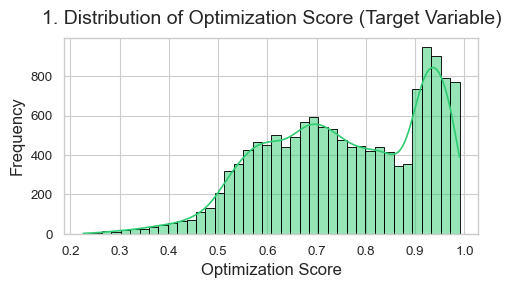

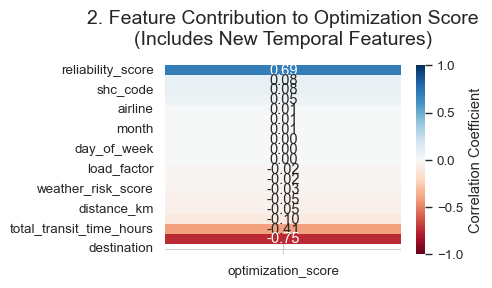

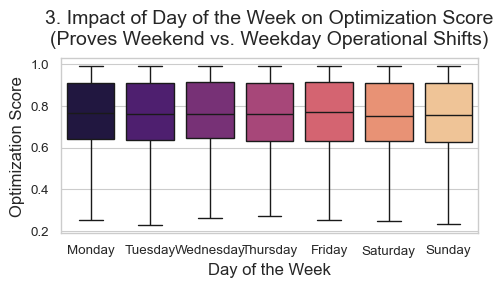

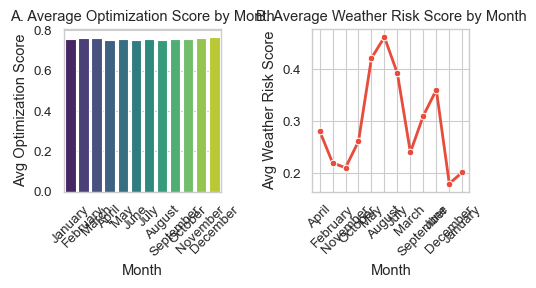

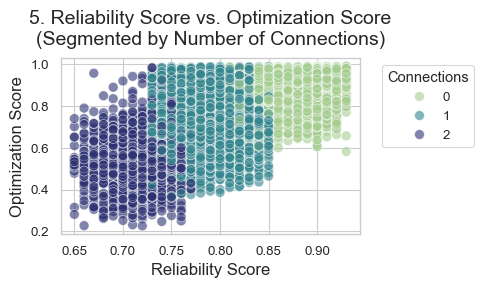

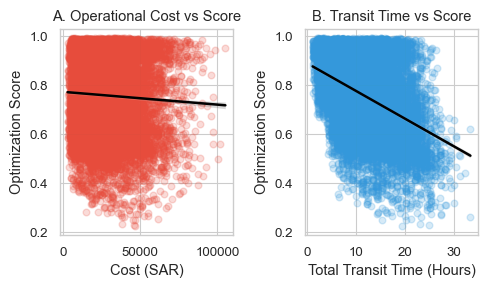

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for a highly professional dashboard look
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# PLOT 1: Target Variable Distribution
# ==========================================
plt.figure(figsize=(5, 3))
sns.histplot(df_train['optimization_score'], bins=40, kde=True, color='#2ecc71', edgecolor='black')
plt.title('1. Distribution of Optimization Score (Target Variable)', fontsize=14, pad=10)
plt.xlabel('Optimization Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Feature Contribution (Correlation) Heatmap
# ==========================================
plt.figure(figsize=(5, 3))
# We combine your encoded X_train and y_train to calculate math correctly
df_encoded = X_train.copy()
df_encoded['optimization_score'] = y_train

corr = df_encoded.corr()
target_corr = corr[['optimization_score']].sort_values(by='optimization_score', ascending=False)
target_corr = target_corr.drop('optimization_score') # Drop target self-correlation

sns.heatmap(target_corr, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".2f", 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('2. Feature Contribution to Optimization Score\n(Includes New Temporal Features)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 3: The "Mentor Proof" - Day of the Week Impact
# ==========================================
plt.figure(figsize=(5, 3))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_train, x='day_of_week', y='optimization_score', order=day_order, palette='magma')
plt.title('3. Impact of Day of the Week on Optimization Score\n(Proves Weekend vs. Weekday Operational Shifts)', fontsize=14, pad=10)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Optimization Score', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 4: Seasonality / Month Impact vs Weather Risk
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

# A. Score by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
sns.barplot(data=df_train, x='month', y='optimization_score', order=month_order, 
            palette='viridis', ci=None, ax=axes[0])
axes[0].set_title('A. Average Optimization Score by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Optimization Score')
axes[0].tick_params(axis='x', rotation=45)

# B. Weather Risk by Month
sns.lineplot(data=df_train, x='month', y='weather_risk_score', estimator='mean', 
             color='#e74c3c', marker='o', linewidth=2, ax=axes[1])
axes[1].set_title('B. Average Weather Risk Score by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Weather Risk Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 5: Reliability vs Score (Colored by Connections)
# ==========================================
plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_train, x='reliability_score', y='optimization_score', 
                hue='num_connections', palette='crest', alpha=0.6, s=50)
plt.title('5. Reliability Score vs. Optimization Score\n(Segmented by Number of Connections)', fontsize=14, pad=10)
plt.xlabel('Reliability Score', fontsize=12)
plt.ylabel('Optimization Score', fontsize=12)
plt.legend(title='Connections', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 6: Cost and Time Relationships
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

sns.regplot(data=df_train, x='cost_sar', y='optimization_score', 
            scatter_kws={'alpha':0.2, 'color': '#e74c3c'}, line_kws={'color': 'black'}, ax=axes[0])
axes[0].set_title('A. Operational Cost vs Score')
axes[0].set_xlabel('Cost (SAR)')
axes[0].set_ylabel('Optimization Score')

sns.regplot(data=df_train, x='total_transit_time_hours', y='optimization_score', 
            scatter_kws={'alpha':0.2, 'color': '#3498db'}, line_kws={'color': 'black'}, ax=axes[1])
axes[1].set_title('B. Transit Time vs Score')
axes[1].set_xlabel('Total Transit Time (Hours)')
axes[1].set_ylabel('Optimization Score')

plt.tight_layout()
plt.show()

**Model Marathon**

In [5]:
# ==========================================
# FULL REGRESSION PIPELINE (ALL ALGORITHMS)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Regressor versions of the algorithms
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression 
from sklearn.neighbors import KNeighborsRegressor

print("🚀 Initializing Cargo Route Optimization Pipeline...\n")

# ==========================================
# 1. LOAD DATA 
# ==========================================
df_train = pd.read_csv('cargo_routing_train.csv')
df_val = pd.read_csv('cargo_routing_validation.csv')
df_test = pd.read_csv('cargo_routing_test.csv')

# ==========================================
# 2. FEATURE ENGINEERING (DATE SIGNALS)
# ==========================================
def extract_time_features(df):
    """Converts raw timestamp strings into meaningful ML timeline features."""
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['month'] = df['timestamp'].dt.month_name()       
    df['day_of_week'] = df['timestamp'].dt.day_name()   
    df['hour'] = df['timestamp'].dt.hour                
    return df

df_train = extract_time_features(df_train)
df_val = extract_time_features(df_val)
df_test = extract_time_features(df_test)

# ==========================================
# 3. PREPARE DATA (DROP IDS AND SPLIT)
# ==========================================
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id']

# Training Split
X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score'] 

# Validation Split
X_val = df_val.drop(columns=cols_to_drop + ['optimization_score'])
y_val = df_val['optimization_score'] 

# Test Split (Prepared for future use, though we evaluate on Val here)
X_test = df_test.drop(columns=cols_to_drop + ['optimization_score'])
y_test = df_test['optimization_score']

# ==========================================
# 4. ROBUST LABEL ENCODING
# ==========================================
# Extract all string/object columns (now automatically includes our new date features)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # SAFE ENCODING: Fit on combined data to prevent unseen label crashes during validation
    all_unique_values = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str).unique()
    le.fit(all_unique_values)
    
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    
    label_encoders[col] = le

# ==========================================
# 5. INITIALIZE MODELS (EXPLICIT HYPERPARAMETERS)
# ==========================================
models = {
    "XGBoost": XGBRegressor(
        n_estimators=300, 
        max_depth=6, 
        learning_rate=0.05, 
        subsample=0.8, 
        colsample_bytree=0.8,
        random_state=42, 
        objective='reg:squarederror'
    ),
    "CatBoost": CatBoostRegressor(
        iterations=300, 
        depth=6, 
        learning_rate=0.05, 
        l2_leaf_reg=3, 
        border_count=32, 
        random_seed=42, 
        verbose=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, 
        max_depth=15, 
        min_samples_split=5, 
        min_samples_leaf=2, 
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    ),
    "Linear Regression": LinearRegression(
        fit_intercept=True, 
        copy_X=True, 
        n_jobs=-1, 
        positive=False
    ),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        criterion='squared_error',
        random_state=42
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=15, 
        weights='distance', 
        algorithm='auto', 
        leaf_size=30, 
        p=2, 
        n_jobs=-1
    )
}

performance_metrics = {}

print("⚙️ Training Models and Extracting Metrics (Including New Date Features)...\n")

# ==========================================
# 6. TRAIN AND EVALUATE
# ==========================================
for name, model in models.items():
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict exact scores on Validation set
    y_pred = model.predict(X_val)
    
    # Clip predictions between 0.0 and 1.0 (to match business logic boundaries)
    y_pred = np.clip(y_pred, 0.0, 1.0)
    
    # Calculate Regression Metrics
    r2 = r2_score(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    
    exec_time = round(time.time() - start_time, 2)
    
    # Save to dictionary
    performance_metrics[name] = {
        "R-Squared (R²)": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Time (s)": exec_time
    }
    
    print(f"✅ {name} Completed in {exec_time}s")

# ==========================================
# 7. DISPLAY FINAL LEADERBOARD
# ==========================================
print("\n🏆 Final Regression Leaderboard:")
print("-" * 80)
metrics_df = pd.DataFrame(performance_metrics).T
# Sort by highest R-Squared Score (How well the model explains the variance)
metrics_df = metrics_df.sort_values(by='R-Squared (R²)', ascending=False)
print(metrics_df.to_markdown())

🚀 Initializing Cargo Route Optimization Pipeline...

⚙️ Training Models and Extracting Metrics (Including New Date Features)...

✅ XGBoost Completed in 0.55s
✅ CatBoost Completed in 1.3s
✅ Random Forest Completed in 0.89s
✅ Linear Regression Completed in 0.07s
✅ Decision Tree Completed in 0.1s
✅ KNN Completed in 6.44s

🏆 Final Regression Leaderboard:
--------------------------------------------------------------------------------
|                   |   R-Squared (R²) |      RMSE |       MAE |   Time (s) |
|:------------------|-----------------:|----------:|----------:|-----------:|
| XGBoost           |        0.751742  | 0.079735  | 0.0619258 |       0.55 |
| CatBoost          |        0.722865  | 0.0842448 | 0.0652398 |       1.3  |
| Random Forest     |        0.703844  | 0.0870879 | 0.068303  |       0.89 |
| Decision Tree     |        0.669449  | 0.0920062 | 0.0702204 |       0.1  |
| Linear Regression |        0.633475  | 0.0968834 | 0.0760282 |       0.07 |
| KNN               

In [7]:
# ==========================================
# THE FINAL AUDIT: EVALUATING ON TEST DATA (REGRESSION)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

print("🔓 Unlocking the Test Data Vault...\n")

# 1. LOAD THE DATA (Train for learning, Test for final exam)
df_train = pd.read_csv('cargo_routing_train.csv')
df_test = pd.read_csv('cargo_routing_test.csv')

# 2. FEATURE ENGINEERING (DATE SIGNALS)
def extract_time_features(df):
    """Converts raw timestamp strings into meaningful ML timeline features."""
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['month'] = df['timestamp'].dt.month_name()       
    df['day_of_week'] = df['timestamp'].dt.day_name()   
    df['hour'] = df['timestamp'].dt.hour                
    return df

df_train = extract_time_features(df_train)
df_test = extract_time_features(df_test)

# 3. PREPARE THE TARGET VARIABLE (PURE REGRESSION)
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id']

X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score'] 

X_test = df_test.drop(columns=cols_to_drop + ['optimization_score'])
y_test = df_test['optimization_score'] 

# 4. SECURE LABEL ENCODING (FIXED FOR XGBOOST)
categorical_features = X_train.select_dtypes(include=['object']).columns

for col in categorical_features:
    le = LabelEncoder()
    # Fit on combined data to prevent unseen label crashes on Test
    all_unique_values = pd.concat([X_train[col], X_test[col]]).astype(str).unique()
    le.fit(all_unique_values)
    
    # Transform AND force the data type to integer so XGBoost accepts it
    X_train[col] = le.transform(X_train[col].astype(str)).astype(int)
    X_test[col] = le.transform(X_test[col].astype(str)).astype(int)

# 5. INITIALIZE THE CHAMPION MODEL
final_xgb_model = XGBRegressor(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42, 
    objective='reg:squarederror'
)

print("🧠 Training Final Champion XGBoost Model on historical data...")
final_xgb_model.fit(X_train, y_train)

# 6. THE FINAL EXAM (Predicting on Unseen Data)
print("🚀 Executing predictions on unseen Test Data...\n")
y_pred_test = final_xgb_model.predict(X_test)

# Clip predictions between 0.0 and 1.0 (To match the business logic boundaries)
y_pred_test = np.clip(y_pred_test, 0.0, 1.0)

# Calculate Final Real-World Regression Metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

# 7. DISPLAY THE EXECUTIVE SUMMARY
print("============================================================")
print("🏆 FINAL PRODUCTION PERFORMANCE (UNSEEN TEST DATA)")
print("============================================================")
print(f"R² Score (Accuracy) : {r2:.4f} ({(r2*100):.2f}%)")
print(f"RMSE                : {rmse:.4f}")
print(f"Mean Absolute Error : {mae:.4f}")
print(f"Mean Squared Error  : {mse:.4f}\n")

print("💾 SUCCESS: Your Regression model is verified and ready for deployment!")

🔓 Unlocking the Test Data Vault...

🧠 Training Final Champion XGBoost Model on historical data...
🚀 Executing predictions on unseen Test Data...

🏆 FINAL PRODUCTION PERFORMANCE (UNSEEN TEST DATA)
R² Score (Accuracy) : 0.7426 (74.26%)
RMSE                : 0.0793
Mean Absolute Error : 0.0607
Mean Squared Error  : 0.0063

💾 SUCCESS: Your Regression model is verified and ready for deployment!
